# LFFHG8 Plasmidsaurus Data: What Happened?

This notebook summarizes the full analysis in plain language, with figures.

## Executive takeaway
- A small minority of reads are the expected amplicon (4/4586 mapped to the gBlock reference).
- The majority signal is a different, longer sequence.
- That dominant sequence contains synthetic `R1`-like sequence near both ends, and a long internal segment that aligns to human ribosomal DNA/rRNA loci.
- The gapped reference (`gblock_f1r1_gapped.gb`) improves quality metrics for the minority target-like reads, but does **not** increase target read count.


In [1]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio.Seq import Seq

plt.style.use('seaborn-v0_8-whitegrid')

project_root = Path.cwd()
if not (project_root / 'results').exists():
    project_root = Path('/home/mcn26/project_pi_skr2/mcn26/plasmidsaurus_alignments')

out_dir = project_root / 'results' / 'LFFHG8_1_pcr1_sub5' / 'story_figures'
out_dir.mkdir(parents=True, exist_ok=True)

paths = {
    'reads_fastq': project_root / 'data' / 'reads' / 'LFFHG8_fastq' / 'LFFHG8_1_pcr1_sub5.fastq',
    'ref_gb': project_root / 'data' / 'references' / 'gblock_f1r1_gapped.gb',
    'flagstat_orig': project_root / 'results' / 'LFFHG8_1_pcr1_sub5' / 'LFFHG8_1_pcr1_sub5.flagstat.txt',
    'flagstat_gapped': project_root / 'results' / 'LFFHG8_1_pcr1_sub5_gappedref' / 'LFFHG8_1_pcr1_sub5_gappedref.flagstat.txt',
    'mapped_ids': project_root / 'results' / 'LFFHG8_1_pcr1_sub5' / 'LFFHG8_1_pcr1_sub5.mapped_read_ids.txt',
    'feature_summary': project_root / 'results' / 'LFFHG8_1_pcr1_sub5' / 'LFFHG8_1_pcr1_sub5.feature_coverage.summary.tsv',
    'primer_summary': project_root / 'results' / 'LFFHG8_1_pcr1_sub5' / 'primer_positive_3.vs_gblock.sr.summary.tsv',
    'mapped_compare': project_root / 'results' / 'LFFHG8_1_pcr1_sub5_gappedref' / 'mapped4_ref_compare.tsv',
    'consensus_fa': project_root / 'results' / 'LFFHG8_1_pcr1_sub5' / 'LFFHG8_1_pcr1_sub5.consensus.fasta',
    'consensus_summary': project_root / 'results' / 'LFFHG8_1_pcr1_sub5' / 'LFFHG8_1_pcr1_sub5.consensus_summary.tsv',
    'blast_txt': project_root / 'results' / 'LFFHG8_1_pcr1_sub5' / 'LFFHG8_contaminant_seed_UBZG1Y0H016_core_nt_blast_alignment.txt',
}

for k, p in paths.items():
    if not p.exists():
        raise FileNotFoundError(f"Missing required file for notebook: {k} -> {p}")

paths

{'reads_fastq': PosixPath('/home/mcn26/project_pi_skr2/mcn26/plasmidsaurus_alignments/data/reads/LFFHG8_fastq/LFFHG8_1_pcr1_sub5.fastq'),
 'ref_gb': PosixPath('/home/mcn26/project_pi_skr2/mcn26/plasmidsaurus_alignments/data/references/gblock_f1r1_gapped.gb'),
 'flagstat_orig': PosixPath('/home/mcn26/project_pi_skr2/mcn26/plasmidsaurus_alignments/results/LFFHG8_1_pcr1_sub5/LFFHG8_1_pcr1_sub5.flagstat.txt'),
 'flagstat_gapped': PosixPath('/home/mcn26/project_pi_skr2/mcn26/plasmidsaurus_alignments/results/LFFHG8_1_pcr1_sub5_gappedref/LFFHG8_1_pcr1_sub5_gappedref.flagstat.txt'),
 'mapped_ids': PosixPath('/home/mcn26/project_pi_skr2/mcn26/plasmidsaurus_alignments/results/LFFHG8_1_pcr1_sub5/LFFHG8_1_pcr1_sub5.mapped_read_ids.txt'),
 'feature_summary': PosixPath('/home/mcn26/project_pi_skr2/mcn26/plasmidsaurus_alignments/results/LFFHG8_1_pcr1_sub5/LFFHG8_1_pcr1_sub5.feature_coverage.summary.tsv'),
 'primer_summary': PosixPath('/home/mcn26/project_pi_skr2/mcn26/plasmidsaurus_alignments/results

In [2]:
def read_fastq_table(fastq_path: Path) -> pd.DataFrame:
    rows = []
    with fastq_path.open() as fh:
        while True:
            h = fh.readline().strip()
            if not h:
                break
            seq = fh.readline().strip()
            fh.readline()
            fh.readline()
            rid = h[1:].split()[0]
            rows.append({'read_id': rid, 'length': len(seq), 'seq': seq})
    return pd.DataFrame(rows)


def parse_flagstat(flagstat_path: Path):
    total = mapped = None
    for line in flagstat_path.read_text().splitlines():
        m_total = re.match(r'^(\d+) \+ \d+ in total', line)
        m_mapped = re.match(r'^(\d+) \+ \d+ mapped', line)
        if m_total:
            total = int(m_total.group(1))
        if m_mapped:
            mapped = int(m_mapped.group(1))
    return total, mapped


def load_primers_from_gb(gb_path: Path):
    rec = SeqIO.read(gb_path, 'genbank')
    ref_seq = rec.seq
    primers = {}
    for feat in rec.features:
        if feat.type != 'primer':
            continue
        label = feat.qualifiers.get('label', ['unnamed_primer'])[0]
        start0 = int(feat.location.start)
        end0 = int(feat.location.end)
        templ = str(ref_seq[start0:end0]).upper()
        if feat.location.strand == -1:
            primer = str(Seq(templ).reverse_complement())
        else:
            primer = templ
        primers[label] = {
            'primer_seq': primer,
            'template_seq': templ,
            'start_1based': start0 + 1,
            'end_1based': end0,
            'strand': feat.location.strand,
        }
    return primers

reads_df = read_fastq_table(paths['reads_fastq'])
primers = load_primers_from_gb(paths['ref_gb'])

f1_seq = primers['F1 primer']['primer_seq']
r1_seq = primers['R1 primer']['primer_seq']
r1_rc = str(Seq(r1_seq).reverse_complement())

reads_df['f1_pos'] = reads_df['seq'].str.find(f1_seq)
reads_df['has_f1'] = reads_df['f1_pos'] >= 0
reads_df['has_r1'] = reads_df['seq'].str.contains(r1_seq)

mapped_ids = [x.strip() for x in paths['mapped_ids'].read_text().splitlines() if x.strip()]
reads_df['is_mapped_to_gblock'] = reads_df['read_id'].isin(mapped_ids)

total_reads, mapped_reads = parse_flagstat(paths['flagstat_orig'])
total_reads_gapped, mapped_reads_gapped = parse_flagstat(paths['flagstat_gapped'])

feature_summary = pd.read_csv(paths['feature_summary'], sep='	')
primer_summary = pd.read_csv(paths['primer_summary'], sep='	')
mapped_compare = pd.read_csv(paths['mapped_compare'], sep='	')
cons_summary = pd.read_csv(paths['consensus_summary'], sep='	')

cons_rec = next(SeqIO.parse(paths['consensus_fa'], 'fasta'))
consensus_seq = str(cons_rec.seq).upper()

primer41 = 'CTGCAGTGACTTTAATATACGCTATTGGAGCTGGAATTACC'
primer41_pos = consensus_seq.find(primer41)
left_r1_pos = consensus_seq.find(r1_seq)
right_r1rc_pos = consensus_seq.find(r1_rc)

summary = {
    'total_reads': total_reads,
    'mapped_reads': mapped_reads,
    'mapped_pct': mapped_reads / total_reads * 100,
    'f1_positive_reads': int(reads_df['has_f1'].sum()),
    'consensus_length': len(consensus_seq),
    'consensus_seed_mapped_reads': cons_summary.loc[0, 'mapped_reads'],
    'left_r1_pos_1based': left_r1_pos + 1 if left_r1_pos >= 0 else None,
    'right_r1rc_pos_1based': right_r1rc_pos + 1 if right_r1rc_pos >= 0 else None,
    'primer41_pos_1based': primer41_pos + 1 if primer41_pos >= 0 else None,
}

summary

{'total_reads': 4586,
 'mapped_reads': 4,
 'mapped_pct': 0.08722197993894462,
 'f1_positive_reads': 3,
 'consensus_length': 1611,
 'consensus_seed_mapped_reads': '1046 (21.54)',
 'left_r1_pos_1based': 7,
 'right_r1rc_pos_1based': 1591,
 'primer41_pos_1based': None}

## 1) Target mapping is rare
Only a tiny fraction of reads map to the expected gBlock amplicon reference.

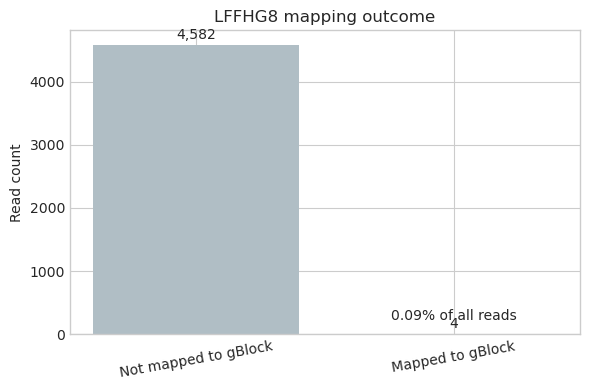

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
vals = [summary['total_reads'] - summary['mapped_reads'], summary['mapped_reads']]
labels = ['Not mapped to gBlock', 'Mapped to gBlock']
colors = ['#b0bec5', '#2a9d8f']
ax.bar(labels, vals, color=colors)
ax.set_ylabel('Read count')
ax.set_title('LFFHG8 mapping outcome')
for i, v in enumerate(vals):
    ax.text(i, v + max(vals) * 0.01, f'{v:,}', ha='center', va='bottom', fontsize=10)
ax.text(1, vals[1] + max(vals) * 0.05, f"{summary['mapped_pct']:.2f}% of all reads", ha='center', fontsize=10)
plt.xticks(rotation=10)
plt.tight_layout()
fig.savefig(out_dir / '01_mapping_outcome.png', dpi=180)
plt.show()

## 2) The expected product exists, but as a minority
Forward-primer-positive reads are present and have expected amplicon-like lengths (~300 bp), but they are rare compared with the full dataset.

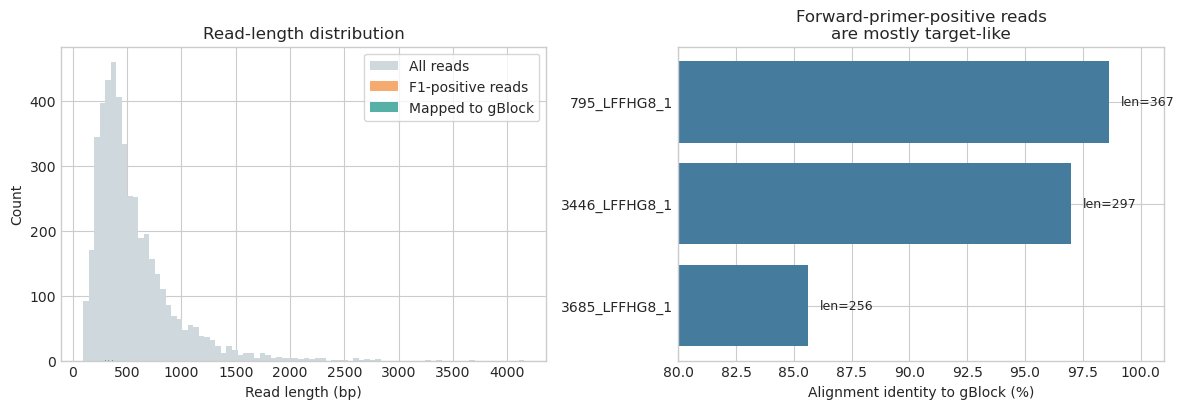

,read_id,length,f1_pos
3446,3446_LFFHG8_1,297,0
3685,3685_LFFHG8_1,256,0
795,795_LFFHG8_1,367,0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].hist(reads_df['length'], bins=80, color='#cfd8dc', edgecolor='none', label='All reads')
axes[0].hist(reads_df.loc[reads_df['has_f1'], 'length'], bins=20, color='#f4a261', alpha=0.9, label='F1-positive reads')
axes[0].hist(reads_df.loc[reads_df['is_mapped_to_gblock'], 'length'], bins=20, color='#2a9d8f', alpha=0.8, label='Mapped to gBlock')
axes[0].set_xlabel('Read length (bp)')
axes[0].set_ylabel('Count')
axes[0].set_title('Read-length distribution')
axes[0].legend(frameon=True)

plot_df = primer_summary.copy()
plot_df = plot_df.sort_values('qlen')
axes[1].barh(plot_df['query'], plot_df['identity'] * 100, color='#457b9d')
for y, (_, row) in enumerate(plot_df.iterrows()):
    axes[1].text(row['identity'] * 100 + 0.5, y, f"len={int(row['qlen'])}", va='center', fontsize=9)
axes[1].set_xlim(80, 101)
axes[1].set_xlabel('Alignment identity to gBlock (%)')
axes[1].set_title('Forward-primer-positive reads\nare mostly target-like')

plt.tight_layout()
fig.savefig(out_dir / '02_length_and_primer_positive.png', dpi=180)
plt.show()

reads_df.loc[reads_df['has_f1'], ['read_id', 'length', 'f1_pos']].sort_values('read_id')

## 3) Coverage over annotated reference features
For the few mapped reads, coverage spans expected annotated regions including primer features and internal annotations.

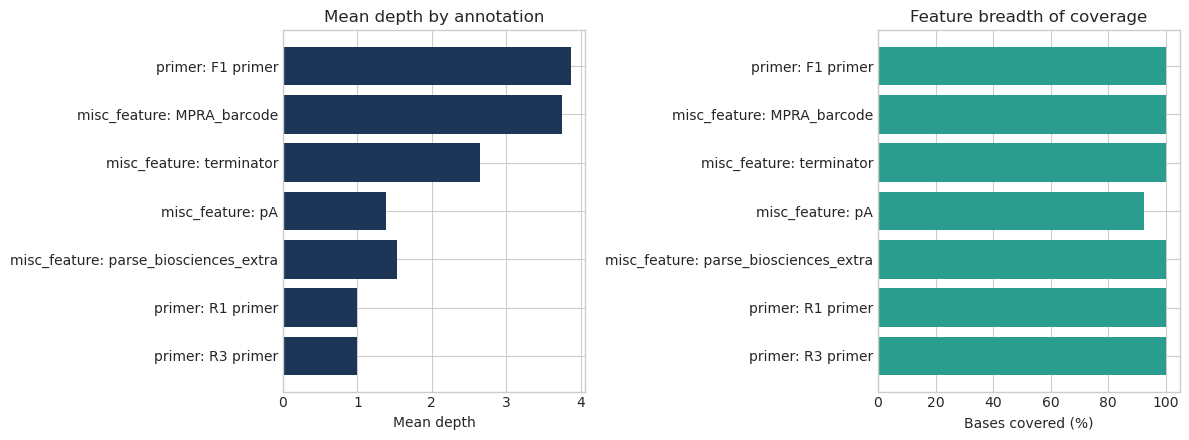

In [5]:
feat_plot = feature_summary[['feature_id', 'feature_type', 'mean_depth', 'frac_bases_covered']].copy()
feat_plot['label'] = feat_plot['feature_type'] + ': ' + feat_plot['feature_id']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].barh(feat_plot['label'], feat_plot['mean_depth'], color='#1d3557')
axes[0].set_xlabel('Mean depth')
axes[0].set_title('Mean depth by annotation')

axes[1].barh(feat_plot['label'], feat_plot['frac_bases_covered'] * 100, color='#2a9d8f')
axes[1].set_xlabel('Bases covered (%)')
axes[1].set_xlim(0, 105)
axes[1].set_title('Feature breadth of coverage')

for ax in axes:
    ax.invert_yaxis()

plt.tight_layout()
fig.savefig(out_dir / '03_feature_coverage.png', dpi=180)
plt.show()

## 4) Gapped reference helps quality, not sensitivity
Replacing barcode bases with ambiguity (`N`) did not increase the number of mapped reads, but improved alignment quality metrics for the mapped minority.

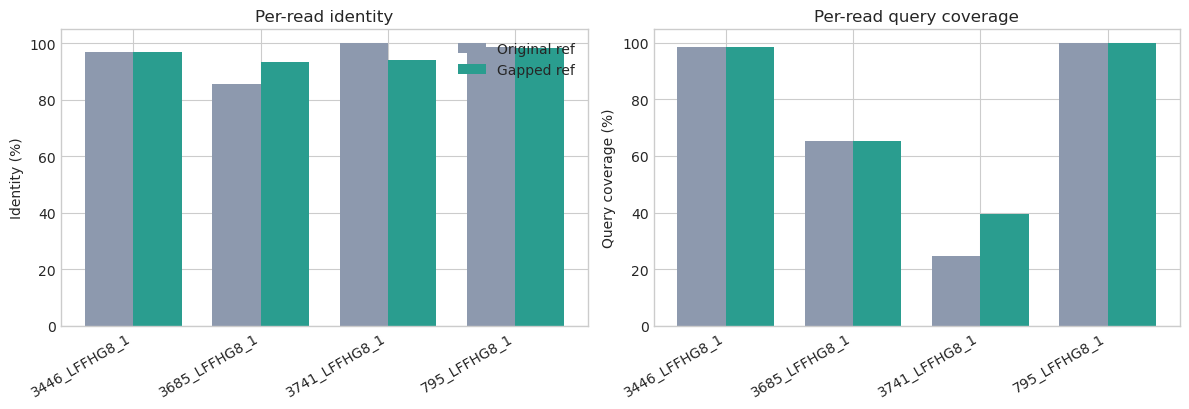

,read_id,orig_identity,gapped_identity,delta_identity,orig_query_cov,gapped_query_cov,delta_query_cov,orig_ref_span,gapped_ref_span
0,3446_LFFHG8_1,0.9700,0.9701,0.0001,0.9865,0.9865,0.0000,300,300
1,3685_LFFHG8_1,0.8563,0.9338,0.0775,0.6523,0.6523,0.0000,163,163
2,3741_LFFHG8_1,1.0000,0.9397,-0.0603,0.2454,0.3957,0.1503,80,128
3,795_LFFHG8_1,0.9864,0.9842,-0.0021,0.9973,0.9973,0.0000,367,367


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

x = np.arange(len(mapped_compare))
w = 0.38

axes[0].bar(x - w/2, mapped_compare['orig_identity'] * 100, width=w, label='Original ref', color='#8d99ae')
axes[0].bar(x + w/2, mapped_compare['gapped_identity'] * 100, width=w, label='Gapped ref', color='#2a9d8f')
axes[0].set_xticks(x)
axes[0].set_xticklabels(mapped_compare['read_id'], rotation=30, ha='right')
axes[0].set_ylabel('Identity (%)')
axes[0].set_title('Per-read identity')
axes[0].legend()

axes[1].bar(x - w/2, mapped_compare['orig_query_cov'] * 100, width=w, label='Original ref', color='#8d99ae')
axes[1].bar(x + w/2, mapped_compare['gapped_query_cov'] * 100, width=w, label='Gapped ref', color='#2a9d8f')
axes[1].set_xticks(x)
axes[1].set_xticklabels(mapped_compare['read_id'], rotation=30, ha='right')
axes[1].set_ylabel('Query coverage (%)')
axes[1].set_title('Per-read query coverage')

plt.tight_layout()
fig.savefig(out_dir / '04_gapped_vs_original.png', dpi=180)
plt.show()

mapped_compare

## 5) Dominant contaminant architecture
The consensus of the dominant sequence cluster is ~1.6 kb and has this structure:
- `R1`-like sequence near the left end.
- Long internal segment that aligns strongly to human 18S/rDNA-related sequence.
- `R1` reverse-complement-like sequence near the right end.

The exact coordinates below are in consensus-space (1-based).

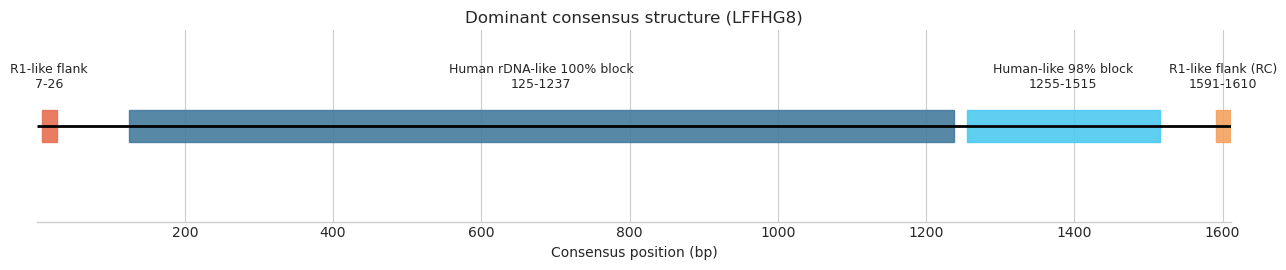

,element,start_1based,end_1based
0,R1-like left flank,7.0,26.0
1,41 bp motif,NaN,NaN
2,Human 100% block,125.0,1237.0
3,Human 98% block,1255.0,1515.0
4,R1-like right flank (RC),1591.0,1610.0


In [7]:
# Coordinates from our previous BLAST/clustal inspection
cons_len = len(consensus_seq)

# From BLAST report against NR_146144.1 section:
perfect_human_start, perfect_human_end = 125, 1237   # 1113/1113, 100%
nearperfect_human_start, nearperfect_human_end = 1255, 1515  # 256/261, 98%

# From direct motif scans on consensus:
left_r1_start = summary['left_r1_pos_1based']
left_r1_end = left_r1_start + len(r1_seq) - 1
right_r1rc_start = summary['right_r1rc_pos_1based']
right_r1rc_end = right_r1rc_start + len(r1_rc) - 1
motif41_start = summary['primer41_pos_1based']
motif41_end = motif41_start + len(primer41) - 1 if motif41_start is not None else None

fig, ax = plt.subplots(figsize=(13, 2.8))
ax.hlines(1, 1, cons_len, color='black', linewidth=2)

# helper
def draw_block(start, end, color, label, y=1, h=0.18):
    ax.add_patch(plt.Rectangle((start, y - h/2), end - start + 1, h, color=color, alpha=0.9))
    ax.text((start + end) / 2, y + 0.2, f"{label}\n{start}-{end}", ha='center', va='bottom', fontsize=9)

draw_block(left_r1_start, left_r1_end, '#e76f51', 'R1-like flank')
draw_block(perfect_human_start, perfect_human_end, '#457b9d', 'Human rDNA-like 100% block')
draw_block(nearperfect_human_start, nearperfect_human_end, '#4cc9f0', 'Human-like 98% block')
draw_block(right_r1rc_start, right_r1rc_end, '#f4a261', 'R1-like flank (RC)')
if motif41_start is not None:
    draw_block(motif41_start, motif41_end, '#6a994e', '41 bp motif', y=0.72, h=0.12)

ax.set_xlim(1, cons_len)
ax.set_ylim(0.45, 1.55)
ax.set_yticks([])
ax.set_xlabel('Consensus position (bp)')
ax.set_title('Dominant consensus structure (LFFHG8)')

for spine in ['left', 'right', 'top']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
fig.savefig(out_dir / '05_consensus_architecture.png', dpi=180)
plt.show()

pd.DataFrame([
    {'element': 'R1-like left flank', 'start_1based': left_r1_start, 'end_1based': left_r1_end},
    {'element': '41 bp motif', 'start_1based': motif41_start, 'end_1based': motif41_end},
    {'element': 'Human 100% block', 'start_1based': perfect_human_start, 'end_1based': perfect_human_end},
    {'element': 'Human 98% block', 'start_1based': nearperfect_human_start, 'end_1based': nearperfect_human_end},
    {'element': 'R1-like right flank (RC)', 'start_1based': right_r1rc_start, 'end_1based': right_r1rc_end},
])

## Final interpretation
The data support this narrative:
1. The intended amplicon is present, but in a very small fraction of reads.
2. Most sequence mass comes from a different template with human rDNA/18S-like content.
3. Synthetic `R1`-like sequence on both ends of the dominant contaminant is consistent with adapter/primer carry-through and nonspecific amplification.
4. Using a gapped reference helps align the minority target reads a bit better, but does not change the core conclusion that this run is dominated by off-target material.

Figures were written to:
- `results/LFFHG8_1_pcr1_sub5/story_figures/`
